## Biomass & Global Energy Analytics: Explaining GridDB Through the Settlers of Catan Board Game

## Introduction

<p> When you first look at Biomass and Global Energy data, all you see is a list of top producers and top consumers, and a bunch of raw production numbers. However, upon close examination, you see that Biomass data has patterns often seen while playing the board game of Catan. You'll see that, while some regions may have low biomass yields, their geographic positioning is a strategic advantage. Moreover, when a low-production resource becomes rare across the system, its value increases rapidly. In this article, we will uncover such insights and patterns using GridDB powerful storage and query engines. GridDB is a powerful NoSQL database designed to handle large volumes of data, optimized for time-series data collected in real-time. While it has a specialized time-series container, it also offers a 'Collections' container for storing longitudinal and panel data, often used in energy datasets. Refer to this resource to learn more about <a href = "https://docs.griddb.net/architecture/data-model.html"> GridDB's data model. </a></p>    

<p> As we work to uncover insights in the biomass data landscape, we also assess GridDB's SQL capabilities as part of its NewSQL offering.
Let's get started with our Catan-style analogy and insights. </p>

In [16]:
from IPython.display import Image, display, Markdown

image_path = "Images/aksel-fristrup-w7eaCH6ShR4-unsplash.jpg"

display(Markdown(
    "<div style='text-align: center;'>"
    "<img src='Images/aksel-fristrup-w7eaCH6ShR4-unsplash.jpg' width='600'/><br>"
    "<em>From GridDB tables to a Catan-style resource board</em><br>"
    "<span style='font-size:13px;'>"
    "Photo by <a href='https://unsplash.com/@motivesandplaces?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText'>Aksel Fristrup</a> "
    "on <a href='https://unsplash.com/photos/green-and-black-dragon-figurine-w7eaCH6ShR4?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText'>Unsplash</a>"
    "</span>"
    "</div>"
))

#display(Image(filename=image_path))

<div style='text-align: center;'><img src='Images/aksel-fristrup-w7eaCH6ShR4-unsplash.jpg' width='600'/><br><em>From GridDB tables to a Catan-style resource board</em><br><span style='font-size:13px;'>Photo by <a href='https://unsplash.com/@motivesandplaces?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText'>Aksel Fristrup</a> on <a href='https://unsplash.com/photos/green-and-black-dragon-figurine-w7eaCH6ShR4?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText'>Unsplash</a></span></div>

<p> The data used for this analysis is from the U.S Energy Information Administration (EIA) portal. EIA offers an API to enable downloading renewable and non-renewable energy data. For this article, we utilize the densified biomass data and international commodity data.</p> 

## Importing pre-requsite libraries

In [30]:
#File system and I/O operations
import os
from io import BytesIO
# Data manipulation 
import pandas as pd
import numpy as np

# Time functions
import math
import time
from datetime import datetime, timedelta

# Data Gathering
import requests
import zipfile

#Encoding and Serialization
import base64
import json

#Debugging
import http
http.client.HTTPConnection.debuglevel = 0

#Visualization Libraries
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff

In [2]:
os.chdir("Your_working_directory")
#os.getcwd()

Note that an API key is required for the EIA API. This can be obtained by registering at https://www.eia.gov/opendata/register.php. Once you register, an API key will be sent to you upon successful email verification.

## Monthly Biomass Production

In [402]:
url = "https://api.eia.gov/v2/densified-biomass/production-by-region/data/"

params = {
    "frequency": "monthly",
    "data[0]": "production",
    "facets": {},  # optional, can remove if unused
    "offset": 0,
    "length": 5000,
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "api_key": "Enter Your API Key Here"
}

response1 = requests.get(url, params=params)

response1_data = response1.json()

In [403]:
densified_biomass_df = pd.DataFrame(response1_data["response"]["data"])
densified_biomass_df.head()

,period,fuelTypeId,fuelTypeDescription,region,production,production-units
0,2025-10,CBL,Compressed Bricks Log,EAST,0,tons
1,2025-10,CBL,Compressed Bricks Log,SOUTH,0,tons
2,2025-10,CBL,Compressed Bricks Log,US-TOTAL,0,tons
3,2025-10,CBL,Compressed Bricks Log,WEST,0,tons
4,2025-10,WPPS,Wood Pellets Premium Standard,EAST,100543,tons


## International Commodities

In [45]:
url = "https://api.eia.gov/v2/international/data/"

params = {
    "frequency": "monthly",
    "data[0]": "value",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000,
    "api_key": "Enter Your API Key Here"
}

response2 = requests.get(url, params=params)

response2_data = response2.json()
#print(response2_data)

In [46]:
international_commodities_df = pd.DataFrame(response2_data["response"]["data"])

In [47]:
international_commodities_df["value_raw"] = international_commodities_df["value"]
international_commodities_df["value"] = pd.to_numeric(
    international_commodities_df["value_raw"], errors="coerce")
international_commodities_df = international_commodities_df[international_commodities_df["value"].notna()]

In [48]:
international_commodities_df.style.hide(axis="index")
international_commodities_df.head(n=5)

,period,productId,productName,activityId,activityName,countryRegionId,countryRegionName,countryRegionTypeId,countryRegionTypeName,dataFlagId,dataFlagDescription,unitName,value,unit,value_raw
3,2025-12,5,Petroleum and other liquids,5,"Stocks, OECD",CAN,Canada,c,Country,None,None,millions barrels,200.272,MBBL,200.272
9,2025-12,5,Petroleum and other liquids,5,"Stocks, OECD",DEU,Germany,c,Country,None,None,millions barrels,257.149,MBBL,257.149
15,2025-12,5,Petroleum and other liquids,5,"Stocks, OECD",FRA,France,c,Country,None,None,millions barrels,147.522,MBBL,147.522
16,2025-12,5,Petroleum and other liquids,5,"Stocks, OECD",GBR,United Kingdom,c,Country,None,None,millions barrels,68.434,MBBL,68.434
20,2025-12,5,Petroleum and other liquids,5,"Stocks, OECD",ISL,Iceland,c,Country,None,None,millions barrels,0.000,MBBL,0


## Connecting to GridDB

We use GridDB's Web API to send requests for container creation, data ingestion, and data querying. We will first identify the data types in order to store biomass and global energy data.  

In [31]:
username = "xxxx" # Provide your GridDB credentials here
password =   "xxxx"
credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()
#print(f"Encoded credentials: Basic {encoded_credentials}")

In [32]:
#Construct an object to hold the request headers (ensure that you replace the XXX placeholder with the correct value that matches the credentials for your GridDB instance)
#header_obj = {"Authorization":"Basic {EncodedAuthorizationToken}","Content-Type":"application/json; charset=UTF-8","User-Agent":"PostmanRuntime/7.29.0"}

header_obj = {
    "Authorization": f"Basic {encoded_credentials}",  # Add encoded credentials here
    "Content-Type": "application/json", 
    "charset": "UTF-8",
    "User-Agent":"PostmanRuntime/7.29.0"
}

#Construct the base URL based on your GridDB cluster you'd like to connect to (ensure that you replace the placeholders in the URL below with the correct values that correspond to your GridDB instance)
#'https://[host]:[port]/griddb/v2/[clustername]/dbs/[database_name]'
base_url = 'https://[host]:[port]/griddb/v2/[clustername]/dbs/[database_name]/'

## Utility Functions to map GridDB datatypes and Container Structures

In [33]:
INT32_MIN = -2147483648
INT32_MAX = 2147483647

def map_dtype_to_griddb(series):
    """
    Maps Pandas series to GridDB data types.
    Detects INTEGER overflow and upgrades to LONG.
    """

    if pd.api.types.is_integer_dtype(series):

        # Check integer overflow
        if series.dropna().between(INT32_MIN, INT32_MAX).all():
            return "INTEGER"
        else:
            return "LONG"

    elif pd.api.types.is_float_dtype(series):
        return "DOUBLE"

    elif pd.api.types.is_bool_dtype(series):
        return "BOOL"

    elif pd.api.types.is_datetime64_any_dtype(series):
        return "TIMESTAMP"

    else:
        return "STRING"

In [41]:
def generate_griddb_data_obj(df, container_name="MyContainer", container_type="COLLECTION", rowkey=False):
    columns = []
    for col in df.columns:
        griddb_type = map_dtype_to_griddb(df[col])
        columns.append({"name": col, "type": griddb_type})
    
    data_obj = {
        "container_name": container_name,
        "container_type": container_type,
        "rowkey": rowkey,
        "columns": columns
    }
    
    return data_obj

## Creating the containers for biomass and international commodities

In [42]:
data_obj = generate_griddb_data_obj(densified_biomass_df, container_name="densified_biomass_data")

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj, headers = header_obj)
#x.text

In [49]:
data_obj = generate_griddb_data_obj(international_commodities_df, container_name="international_commodities_data")

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj, headers = header_obj)
#x.text

## Ingesting Data into the Containers (Row Registration)

GridDB enables registering rows into a container via the API. Refer to this <a href = "https://griddb.org/docs/30_reference_api/18.md_reference_web_api/md_reference_web_api/"> GridDB resource </a> to learn more.

### Ingesting Data into the Densified Biomass Data Container

In [ ]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/densified_biomass_data/rows'
print(url)

In [ ]:
batch_size = 5000
total_rows = len(densified_biomass_df)
total_batches = math.ceil(total_rows / batch_size)

print(f"Starting ingestion of {total_rows:,} rows in {total_batches} batches of {batch_size} each...")
start_time = time.time()

for i in range(total_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, total_rows)
    batch_df = densified_biomass_df.iloc[start_idx:end_idx]
    batch_json = batch_df.to_json(orient='values')
    
    try:
        print(url)
        response = requests.put(url, headers=header_obj, data=batch_json)
        elapsed = time.time() - start_time

        if response.status_code in [200, 201]:
            print(f" Batch {i+1}/{total_batches} | Rows {start_idx}-{end_idx-1} | "
                  f"Time elapsed: {elapsed:.1f}s")
        else:
            print(f" Batch {i+1}/{total_batches} FAILED "
                  f"(HTTP {response.status_code}) - {response.text[:150]}")

    except Exception as e:
        print(f" Batch {i+1}/{total_batches} ERROR: {e}")

print(f"\n Ingestion completed in {time.time() - start_time:.1f} seconds.")

### Ingesting data into the International commodities container 

In [ ]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/international_commodities_data/rows'
print(url)

In [ ]:
batch_size = 5000
total_rows = len(international_commodities_df)
total_batches = math.ceil(total_rows / batch_size)

print(f"Starting ingestion of {total_rows:,} rows in {total_batches} batches of {batch_size} each...")
start_time = time.time()

for i in range(total_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, total_rows)
    batch_df = international_commodities_df.iloc[start_idx:end_idx]
    batch_json = batch_df.to_json(orient='values')
    
    try:
        print(url)
        response = requests.put(url, headers=header_obj, data=batch_json)
        elapsed = time.time() - start_time

        if response.status_code in [200, 201]:
            print(f" Batch {i+1}/{total_batches} | Rows {start_idx}-{end_idx-1} | "
                  f"Time elapsed: {elapsed:.1f}s")
        else:
            print(f" Batch {i+1}/{total_batches} FAILED "
                  f"(HTTP {response.status_code}) - {response.text[:150]}")

    except Exception as e:
        print(f" Batch {i+1}/{total_batches} ERROR: {e}")

print(f"\n Ingestion completed in {time.time() - start_time:.1f} seconds.")

## Analysis using SQL

### Total Monthly Production by Resource Category

We start our analysis with a simple CASE WHEN statement and an aggregation. Here, we categorize each resource by fuel type and calculate the total production for each type.

In [171]:
sql_query1 = ("""
            SELECT CASE WHEN LOWER(fueltypedescription) like '%wood%'
            THEN 'Wood'
            WHEN LOWER(fueltypedescription) like '%brick%'
            THEN 'Brick'
            ELSE 'Others'
            END AS Resource_Category,
            CAST(ROUND(sum(cast(production as INTEGER)), 1) AS FLOAT(12,1)) as "Total Monthly Production"
            FROM
            densified_biomass_data d
            GROUP BY 1
            """)

# fueltypedescription AS "Resource/Fuel", 

In [172]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query1
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req1 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req1.json()
occurrences_df = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"]])

In [177]:
occurrences_df = occurrences_df.reset_index(drop=True)

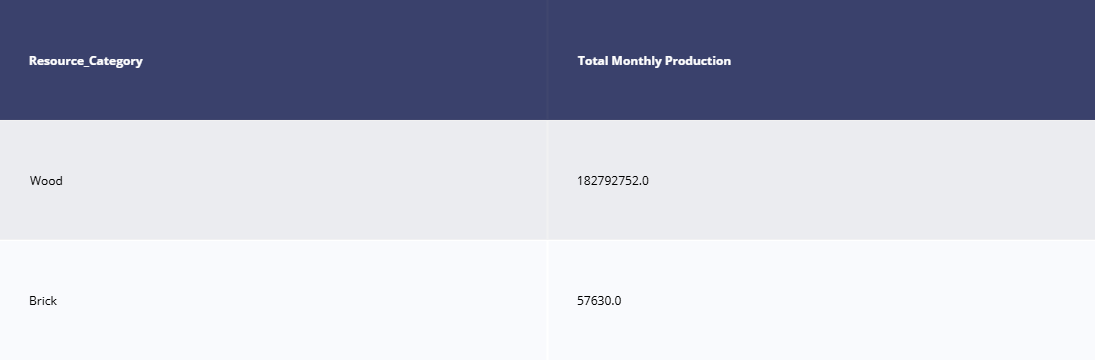

In [178]:
fig = ff.create_table(occurrences_df)
fig.show()

<b> Insights: </b> Here, we see a highly imbalanced production landscape, with wood clearly dominating the scene. Since this dataset is sourced from the US EIA, this reflects the US market, which is dominated by wood pellets, chips, and residue. This is quite the opposite of what's seen in a Catan board, where resources are usually balanced (4:3 ratio of wood and brick). If we were to visualize our actual real-world insight on a Catan board, the board would be filled with forest hex tiles, with only one brick tile tucked away somewhere.

<div style='text-align: center;'><em>An Imbalanced Production Landscape - Catan Analogy </em><br><span style='font-size:13px;'></span></div>

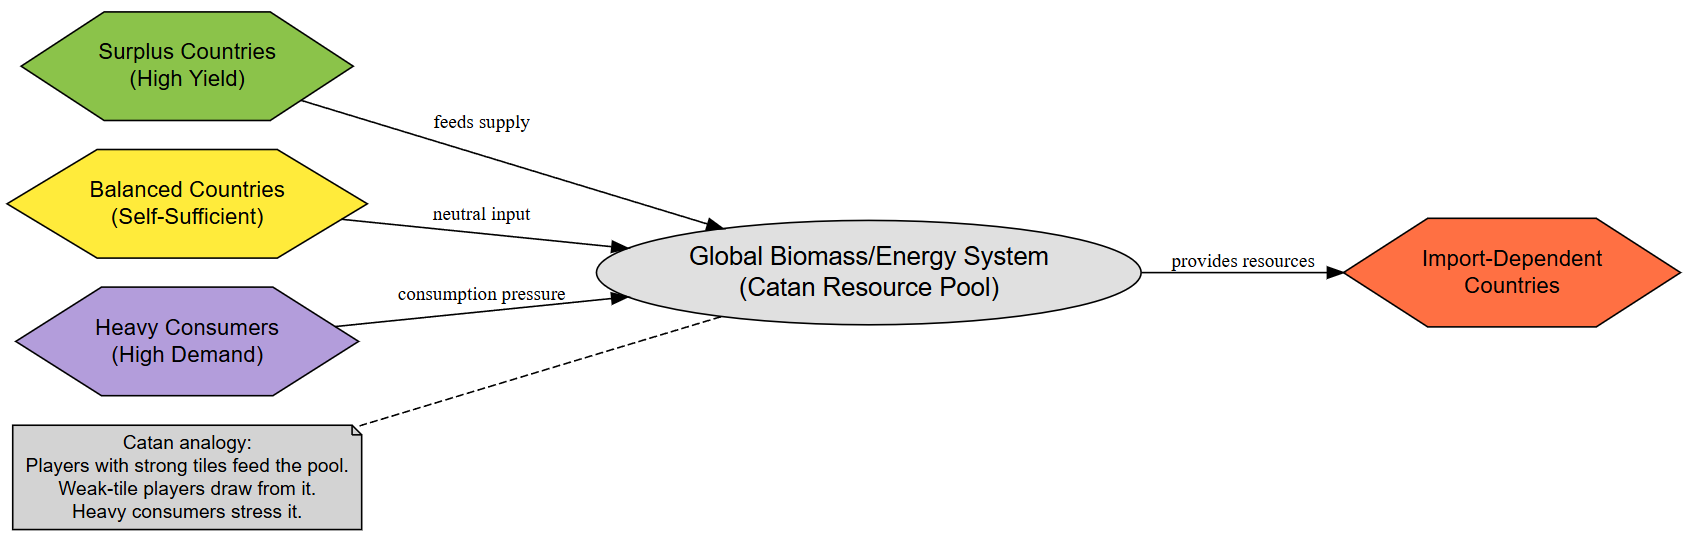

In [6]:
image_path = "Images/Query1_Catan_Style_Insight.png"

display(Markdown(
    "<div style='text-align: center;'>"
    "<em>An Imbalanced Production Landscape - Catan Analogy </em><br>"
    "<span style='font-size:13px;'></span>"
    "</div>"
))

display(Image(filename=image_path))

## Distribution of Resources by Region

Here, we try to determine whether there is a pattern in the geographic distribution of resources. To do this, we categorize the resource by type (wood, brick, etc.). We then sum up the production for each resource type and format the output in billions, millions, or plain tons. To explore the aggregation operations offered by GridDB, refer to <a href = "https://docs.griddb.net/sqlreference/sql-commands-supported.html#aggregate-functions"> this resource. </a>

In [250]:
sql_query2 = ("""
            SELECT
            region,
            CASE 
            WHEN LOWER(fueltypedescription) LIKE '%wood%' THEN 'Wood'
            WHEN LOWER(fueltypedescription) LIKE '%brick%' THEN 'Brick'
            ELSE 'Others'
            END AS Resource_Category,
            fueltypedescription,
            CASE 
            WHEN SUM(CAST(production AS INTEGER)) >= 1000000000 THEN 
                CAST(ROUND(SUM(CAST(production AS INTEGER)) / 1000000000.0, 1) AS STRING) || ' B' || ' tons'
            WHEN SUM(CAST(production AS INTEGER)) >= 1000000 THEN 
                CAST(ROUND(SUM(CAST(production AS INTEGER)) / 1000000.0, 1) AS STRING) || ' M' || ' tons'
            ELSE 
                CAST(ROUND(SUM(CAST(production AS INTEGER)), 1) AS STRING) || ' tons'
            END AS "Total_Monthly_Production"
            FROM densified_biomass_data d
            WHERE lower(region) not like '%total%' 
            GROUP BY 1,2,3
            """
             )

In [251]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query2
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req2 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req2.json()
res_dist = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"], myJson[0]["columns"][3]["name"]])

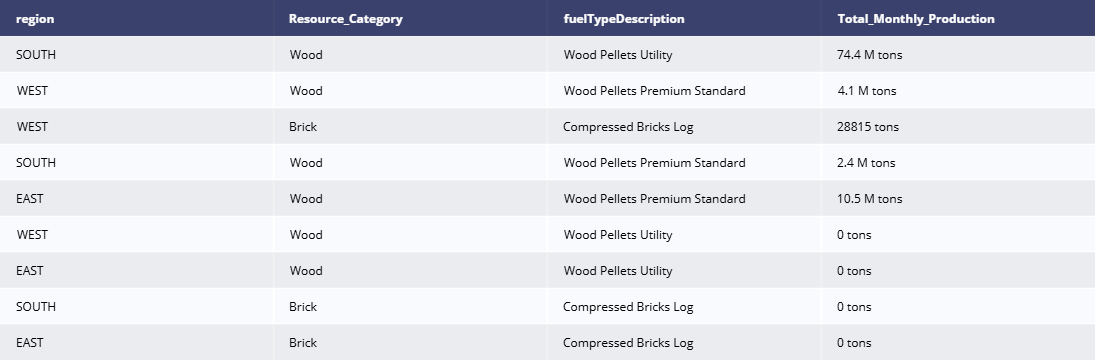

In [253]:
res_dist = res_dist.sort_values(by="Total_Monthly_Production", ascending=False)
fig = ff.create_table(res_dist)
fig.show()

<b> Insight(s): </b> We see that the south produces 74.4 M tons of utility wood pellets, whereas the east produces 10.5 M tons of premium wood pellets. The West produces 4.1 M tons of premium pellets and 28815 tons of bricks. The South seems to be the top producer of biomass, especially wood. If this were a Catan Board, the south would look like a dense jungle followed by the East which would resemble a mid-value forest.

## Analyzing Global Energy Commodities

## Estimating Demand

The US EIA's International Energy Commodity dataset shows the movement of energy resources globally. It provides details on whether a country is a producer, consumer, or importer of a particular energy resource. When visualized as a catan-style board, you would see some zones as heavy production hubs, some as consumption sinks, and a few as storage banks. That's what we try to visualize with our data. We try to find regions that are producers, those that are consumers, and those that are dependent on imports for their sustenance. We use a subquery approach for this. Here is an official resource on <a href = "https://docs.griddb.net/sqlreference/sql-commands-supported.html#subquery"> subqueries in GridDB </a>.

In [382]:
sql_query3 = ("""
            SELECT
            countryRegionName,
            production,
            imports,
            consumption,
            CASE
            WHEN imports > 0 THEN 'Import-dependent'
            WHEN production > consumption THEN 'Producer-only'
            WHEN consumption > production THEN 'Consumption-heavy'
            ELSE 'Balanced'
            END AS role_label,
            (production + imports) AS demand
            FROM (
                SELECT
                countryRegionName,
                SUM(CASE WHEN lower(activityName) LIKE '%prod%' THEN value ELSE 0 END) AS production,
                SUM(CASE WHEN lower(activityName) LIKE '%impor%' THEN value ELSE 0 END) AS imports,
                SUM(CASE WHEN lower(activityName) LIKE '%consum%' THEN value ELSE 0 END) AS consumption
                FROM international_commodities_data
                WHERE activityName NOT LIKE '%Stocks%'
                AND countryRegionName NOT LIKE 'OECD%'
                GROUP BY countryRegionName
                ) AS flows
        ORDER BY (production + imports) DESC;
        """      
    )

In [383]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query3
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req3 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req3.json()
calculated_demand = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"], myJson[0]["columns"][3]["name"], myJson[0]["columns"][4]["name"],myJson[0]["columns"][5]["name"]])

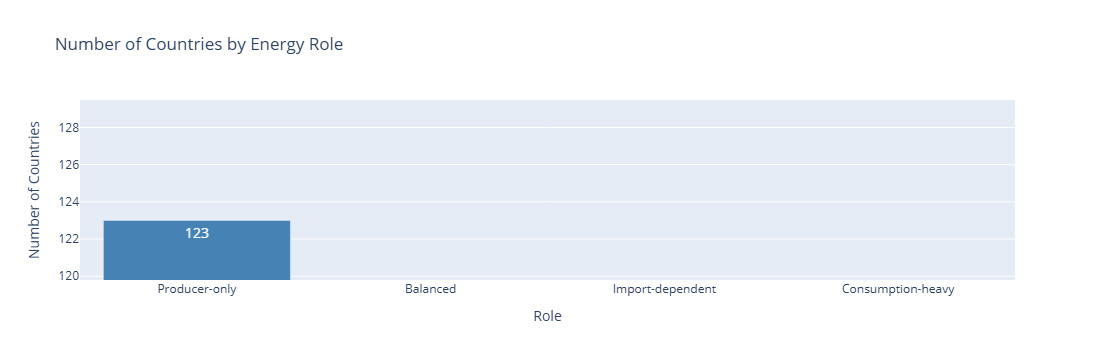

In [384]:
role_counts = calculated_demand["role_label"].value_counts().reset_index()
role_counts.columns = ["role_label", "count"]

fig = px.bar(
    role_counts,
    x="role_label",
    y="count",
    color="role_label",
    text="count",                      
    title="Number of Countries by Energy Role",
    color_discrete_map={
        "Producer-only": "steelblue",
        "Import-dependent": "orange",
        "Consumption-heavy": "crimson",
        "Balanced": "gray"
    }
)

fig.update_traces(
    textposition="auto",          
    textfont_size=14
)

fig.update_layout(
    xaxis_title="Role",
    yaxis_title="Number of Countries",
    showlegend=False,
    uniformtext_minsize=10,
    uniformtext_mode="hide"
)

fig.show()

<b> Insight(s): </b> We see that the majority of the countries not only meet their recorded demand through domestic production but also have some surplus, with no imports in this dataset. The next category, 'Balanced' players, seems to produce exactly what they need in terms of consumption. A small subset of countries is import-dependent to meet their demand. 8 countries seem to be heavy consumers. Viewed through a Catan lens, this resembles the situation in which a few players are lucky enough to start with high-yield resource tiles, demonstrating the asymmetry in the global energy availability landscape.

## Comparing Demand Vs Reported Consumption

In the game of Catan, you may have too many resource cards or may not have enough. Demand is the number of resource cards you wish you had, but Consumption is the number of resource cards you actually use. Similarly, we aim to identify countries with a demand-consumption gap. We use subqueries and JOINs for this approach. This is explained in detail in <a href ="https://docs.griddb.net/sqlreference/sql-commands-supported.html#join"> joins in GridDB. </a> 

In [378]:
sql_query4 = ("""
            SELECT
            d.countryRegionName,
            d.demand,
            c.consumption,
            (d.demand - c.consumption) AS gap,
            CASE
            WHEN (d.demand - c.consumption) > 0 THEN 'Surplus'
            WHEN (d.demand - c.consumption) < 0 THEN 'Deficit'
            ELSE 'Balanced'
            END AS gap_category
            FROM 
                (
                SELECT
                countryRegionName,
                SUM(CASE WHEN lower(activityName) LIKE '%prod%' THEN value ELSE 0 END)
                +
                SUM(CASE WHEN lower(activityName) LIKE '%impor%' THEN value ELSE 0 END)
                AS demand
                FROM international_commodities_data
                WHERE countryRegionName NOT LIKE 'OECD%'
                 AND activityName NOT LIKE '%Stocks%'
                GROUP BY countryRegionName
                ) d
                JOIN 
                (
                SELECT
                countryRegionName,
                SUM(value) AS consumption
                FROM international_commodities_data
                WHERE lower(activityName) LIKE '%consum%'
                and countryRegionName NOT LIKE 'OECD%'
                GROUP BY countryRegionName
                ) c
            ON d.countryRegionName = c.countryRegionName;
            """)

In [379]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query4
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req4 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req4.json()
gap_df = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"], myJson[0]["columns"][3]["name"], myJson[0]["columns"][4]["name"]])

In [380]:
# Top 5 surplus (largest positive gap)
top_surplus = gap_df[gap_df["gap_category"] == "Surplus"].nlargest(5, "gap")

# Top 5 deficit (most negative gap)
top_deficit = gap_df[gap_df["gap_category"] == "Deficit"].nsmallest(5, "gap")
top_combined = pd.concat([top_surplus, top_deficit])

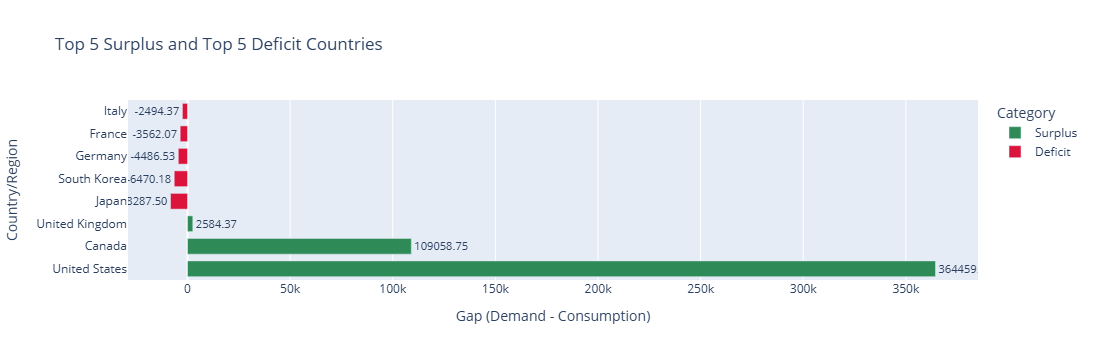

In [381]:
fig = px.bar(
    top_combined,
    x="gap",
    y="countryRegionName",
    color="gap_category",
    orientation="h",
    title="Top 5 Surplus and Top 5 Deficit Countries",
    color_discrete_map={
        "Surplus": "seagreen",
        "Deficit": "crimson",
        "Balanced": "gray"
    },
    text="gap"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

fig.update_layout(
    xaxis_title="Gap (Demand - Consumption)",
    yaxis_title="Country/Region",
    legend_title="Category",
    bargap=0.3,
    height=600
)

fig.show()

<b> Insight(s): </b> The results here show that the US, Canada, and the United Kingdom in terms of supply-demand. However, Germany and South Korea appear to have a supply-and-demand imbalance. This is similar to a Catan board, where some players have high-yield resource tiles that they trade with deficit players. This enables deficit players to trade and exchange resources while staying in the game.   

### OECD Reserves vs OECD and Non‑OECD Output

The next valuable insight would be obtained by placing OECD inventory (stock) along with OECD production and Non-OECD production. OECD Reserves are inventory stocks held by countries that are members of the OECD (also called the 'bloc'). These are strategic, emergency reserves measured in million barrels (MBBL). The OECD output, however, refers to the daily output of commodities produced by OECD member countries. Non-OECD Output measures the daily output of the rest of the world, which is not part of OECD. These production outputs are measured in Thousand Barrels Per Day (TBPD). So, we convert all the units to barrels to be able to bring them to the same scale so as to plot them.

In [392]:
sql_query5 = ("""
            SELECT
            'OECD Stocks (Annualized Equivalent)' AS metric,
            SUM(value * 1000000) AS barrels
            FROM international_commodities_data
            WHERE activityName = 'Stocks, OECD'
            AND countryRegionName = 'OECD'
            
            UNION ALL
            
            SELECT
            'OECD Production (Annual)' AS metric,
            SUM(value * 1000 * 365) AS barrels
            FROM international_commodities_data
            WHERE lower(activityName) LIKE '%prod%'
            AND countryRegionName = 'OECD'
            
            UNION ALL
            
            SELECT
            'Non-OECD Production (Annual)' AS metric,
            SUM(value * 1000 * 365) AS barrels
            FROM international_commodities_data
            WHERE lower(activityName) LIKE '%prod%'
            AND countryRegionName = 'Non-OECD';
            """    
            )

In [394]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query5
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req5 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req5.json()
oecd_vs_non_oecd_df = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"]])

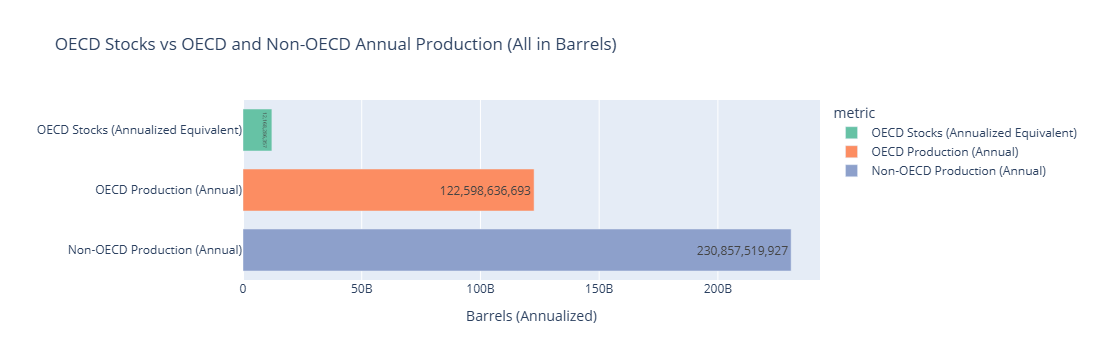

In [400]:
fig = px.bar(
    oecd_vs_non_oecd_df,
    y="metric",
    x="barrels",
    orientation="h",
    text="barrels",
    title="OECD Stocks vs OECD and Non-OECD Annual Production (All in Barrels)",
    color="metric",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    textposition="inside",
    texttemplate="%{x:,.0f}"
)

fig.update_layout(
    xaxis_title="Barrels (Annualized)",
    yaxis_title="",
    uniformtext_minsize=12,
    #uniformtext_mode="hide",
    bargap=0.3,
    height=450
)

fig.show()


<b> Insight(s): </b> We see that the OECD inventory is around 12 billion barrels. OECD member countries produce around 123 billion barrels annually. But non-OECD countries together produce about twice as much (2X) annually as OECD member countries. Though OECD stocks aren't meant to support the entire world, they are meant to protect the member countries. During a global emergency, releasing even a small amount of OECD inventory to the global market can help lessen the severity of oil price spikes and calm things down a bit. This is like that one player in the Catan game who plays strategically and has a well-established resource pool. This player can toss in extra resources during a bid to prevent the game from finishing quickly.

<div style='text-align: center;'><em>OECD Stocks Vs OECD and Non-OECD Production - Catan Analogy </em><br><span style='font-size:13px;'></span></div>

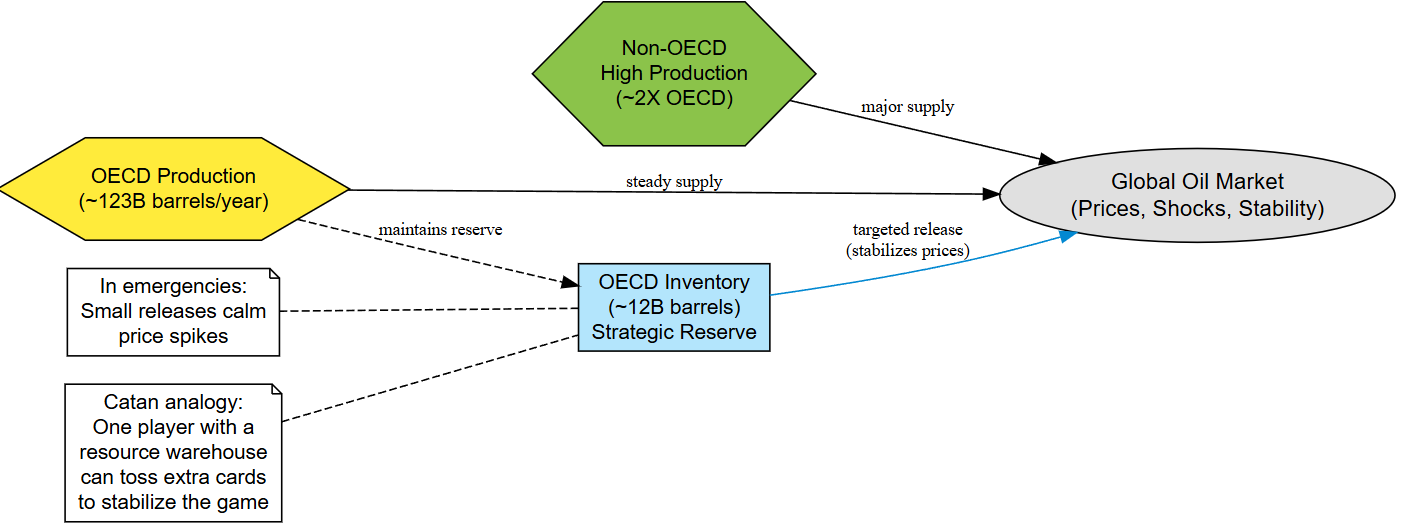

In [7]:
image_path = "Images/Query5_Catan_Style_Insight.png"

display(Markdown(
    "<div style='text-align: center;'>"
    "<em>OECD Stocks Vs OECD and Non-OECD Production - Catan Analogy </em><br>"
    "<span style='font-size:13px;'></span>"
    "</div>"
))

display(Image(filename=image_path))

## Concluding Remarks

We see that the biomass and energy data landscape is similar to Catan, where everyone’s strategy depends on what they intend to build, but the game only moves forward with the resources actually built and traded. And when the board gets tense with sparse resources, the only player with a real stack of high-value resource cards (the OECD stock reserves) can release a few cards to keep the game from ending early. GridDB, along with the Catan analogy, has been invaluable for making resource dynamics easier to interpret. GridDB's NewSQL interface makes querying easy to grasp and intuitive, even for complex queries. The fast retrieval times are an added bonus to such explorations. 